In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

f:\College\6th sem\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\OK\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
print(os.listdir(path))
csv_path = os.path.join(path,"Housing.csv")
data = pd.read_csv(csv_path)
data.head(10)
print(data.describe) #for getting total rows and columns
print(data["bedrooms"])








['Housing.csv']
<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes 

In [4]:
#cleaning data
data.drop_duplicates()

#getting all missing values
print(data.isnull().sum())
#no missing values found but for avoiding casuality
#for features having numerical data
median_price=data["price"].median()
median_area=data["area"].median()
data['price']  = data['price'].fillna(median_price)
data['area']  = data['area'].fillna(median_price)
data = data.dropna()




price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
#for checking the datatypes
print(data.dtypes)
#all columns are having appropriate datatypes
#but in case if price was string
# data_cleaned = data_cleaned.astype(int)
data['price'] = data['price'].astype(str).str.replace(',', '').str.replace('$', '')
data['price'] = pd.to_numeric(data['price'], errors='coerce') #if not able to change into numeric then changed to NaN


price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [8]:
#for changing categorial data into numerical

data['mainroad'] = data['mainroad'].replace({'yes': 1, 'no': 0})
# data['bedrooms'] = data['bedrooms'].replace({'yes': 1, 'no': 0})
# data['bathrooms'] = data['bathrooms'].replace({'yes': 1, 'no': 0})
data['guestroom'] = data['guestroom'].replace({'yes': 1, 'no': 0})
data['hotwaterheating'] =  data['hotwaterheating'].replace({'yes': 1, 'no': 0})
data['airconditioning'] = data['airconditioning'].replace({'yes': 1, 'no': 0})
data['prefarea'] = data['prefarea'].replace({'yes': 1, 'no': 0})
data['basement'] = data['basement'].replace({'yes': 1, 'no': 0})

# Creates new true/false columns for each status
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True, dtype=int)

print(data.dtypes)
data

price                               int64
area                                int64
bedrooms                            int64
bathrooms                           int64
stories                             int64
mainroad                           object
guestroom                          object
basement                           object
hotwaterheating                    object
airconditioning                    object
parking                             int64
prefarea                           object
furnishingstatus_semi-furnished     int64
furnishingstatus_unfurnished        int64
dtype: object


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


<Axes: >

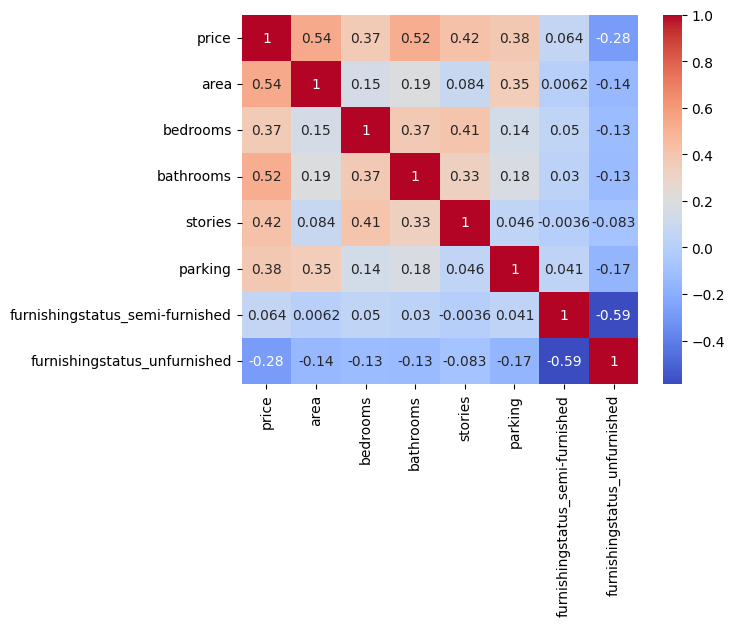

In [9]:
data
corr_matrix = data.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')


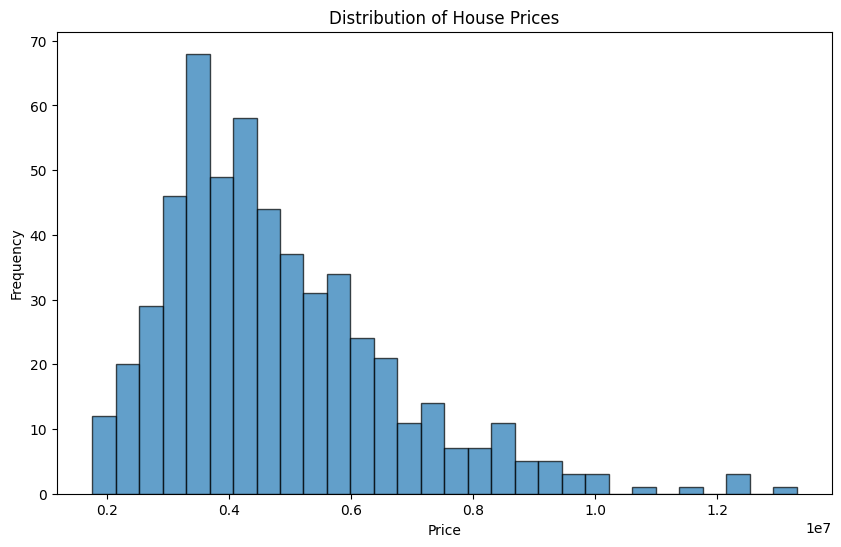

In [10]:
import matplotlib.pyplot as plt
#to present a histogram of the price distribution
plt.figure(figsize=(10, 6))
plt.hist(data['price'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


In [11]:
#model import and training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y = data['price']
X = data.drop('price', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#training linear regression model
model1 = LinearRegression()
model1.fit(X_train, y_train)
#predictiing the values
y_pred = model1.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared:", r2_score(y_test, y_pred))


Mean Squared Error: 1754318687330.6628
Root Mean Squared Error: 1324506.9600914384
R-squared: 0.6529242642153186


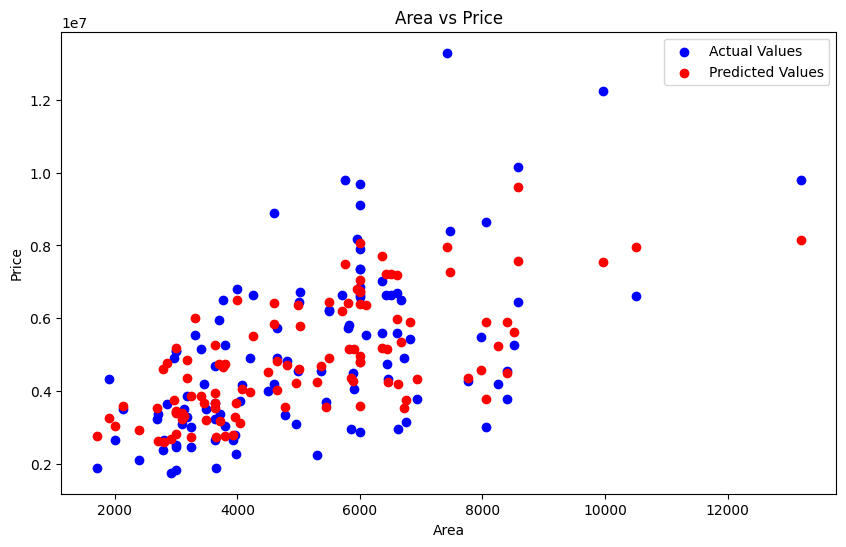

In [13]:
plt.figure(figsize=(10, 6))
#to plot the price vs area graph and predicted and actual values as the scatter plot in that graph
plt.scatter(X_test['area'], y_test, color='blue', label='Actual Values')
plt.scatter(X_test['area'], y_pred, color='red', label='Predicted Values')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.show()

In [14]:
#Random forest regressor
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)
y_pred_rf = model2.predict(X_test)
print("Random Forest Mean Squared Error:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R-squared:", r2_score(y_test, y_pred_rf))


Random Forest Mean Squared Error: 1964193399645.3335
Random Forest Root Mean Squared Error: 1401496.8425384816
Random Forest R-squared: 0.6114024924156645


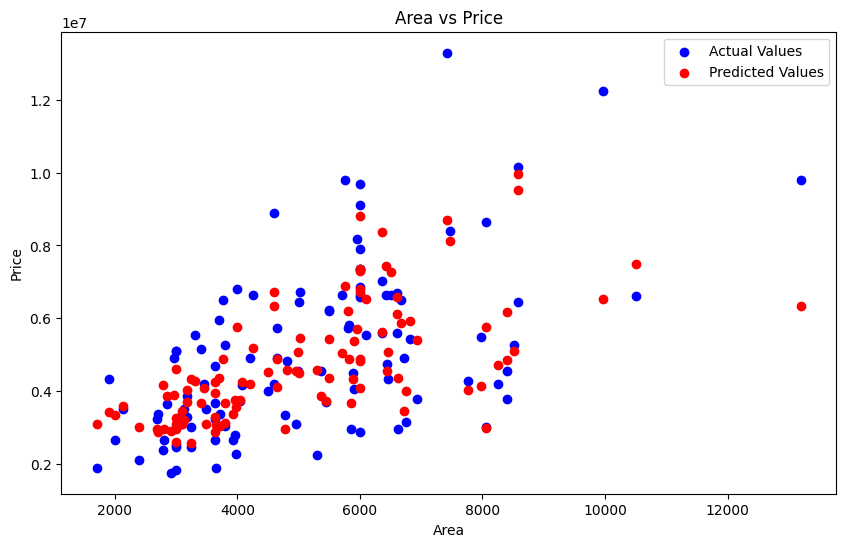

In [15]:
plt.figure(figsize=(10, 6))
#to plot the price vs area graph and predicted and actual values as the scatter plot in that graph
plt.scatter(X_test['area'], y_test, color='blue', label='Actual Values')
plt.scatter(X_test['area'], y_pred_rf, color='red', label='Predicted Values')
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
#Short paragraph on final conclusion 
#1) Important features which influence the prices the most are as follows:
# As per the heatmap and correlation matrix, the most important features for predicting house prices are area, 
# bedrooms, bathrooms, and parking. These features have the highest correlation with the target variable (price). 
# The linear regression model achieved a certain level of accuracy, but the random forest regressor performed better 
# in terms of mean squared error and R-squared value. Therefore, the random forest regressor is a more suitable model 
# for predicting house prices based on the given dataset.

#2) Linear Regression's accuracy is more than Random forest as the mean squared error and R-squared value of 
# linear regression is less than random forest regressor.

#3)The suprised thing is that mainroad is not at all making a correlation with the price and the bedrooms features is not having much influence on the price as per the correlation matrix and heatmap.
#  This could be due to the fact that other features such as area, bathrooms, and parking have a stronger influence on the price,
#  overshadowing the impact of bedrooms.

#4) With the analysis of the dataset, we can conclude that the area of the house is the most significant factor influencing 
# its price, followed by the number of bathrooms and parking spaces. In real estate, larger houses with more amenities tend to command higher prices, which is reflected in the strong 
# correlation between area and price.Recommendations for potential buyers would be to prioritize properties with larger areas and more bathrooms, as these features are likely to contribute
#  to a higher resale value. Additionally, while the presence of a main road may not directly impact the price, it could affect the overall desirability of the location, so buyers should consider 
# the neighborhood and accessibility when making their decision.